# Bearing Autoencoder — One AE, Per-Bearing Dynamic Threshold

**Key idea:**
- A **single** Conv1D autoencoder is trained once on healthy signals (MC nuisance).
- At deployment each physical bearing gets its **own** `AdaptiveTau` instance.
- The sliding window tracks μ and σ *locally* for that bearing → no cross-contamination.
- The z-score anchor `z_MC` is shared (derived from the simulator calibration set).

Steps:
1. Imports & seeds
2. Simulator
3. Generate dataset (healthy train/val + per-regime test)
4. Build & train autoencoder (once)
5. Reconstruction fidelity check
6. Per-regime MSE distributions
7. MC threshold calibration → derive `z_MC`
8. `AdaptiveTau` class — per-bearing sliding window
9. **Per-bearing experiment** — each bearing gets its own tracker
10. Window size sensitivity
11. Latent space PCA
12. Summary

## 0. Imports & seeds

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)
print('TF version:', tf.__version__)

TF version: 2.16.2


## 1. Simulator

In [2]:
from bearing_simulator import BearingSignalSimulator

sim = BearingSignalSimulator()
SIG_LEN = len(sim.t)
print(f'Signal length: {SIG_LEN} samples')

Signal length: 1200 samples


## 2. Generate dataset

- **Train / Val:** healthy only (MC) — the AE sees only M_healthy
- **Test:** all four regimes — never used for training

> Each test split is kept **separate** so we can simulate *independent bearings* later.
> There is no mixing between regimes at this stage.

In [3]:
REGIMES = ['healthy', 'outer_race', 'inner_race', 'ball_fault']
COLORS  = ['#01696f', '#a12c7b', '#da7101', '#006494']
LABELS  = ['Healthy', 'Outer Race', 'Inner Race', 'Ball Fault']

N_TRAIN = 800   # healthy train
N_VAL   = 200   # healthy val  (also used for MC calibration)
N_TEST  = 200   # per regime

# ── Healthy train/val ──────────────────────────────────────────────────────
X_healthy = np.array([sim.sample('healthy', mc=True)
                       for _ in range(N_TRAIN + N_VAL)])
scaler = StandardScaler()
X_healthy_sc = scaler.fit_transform(X_healthy)

X_train = X_healthy_sc[:N_TRAIN, :, np.newaxis].astype('float32')
X_val   = X_healthy_sc[N_TRAIN:, :, np.newaxis].astype('float32')

# ── Test sets — one array PER regime (kept separate) ──────────────────────
X_test_by_regime = {}
for regime in REGIMES:
    sigs = np.array([sim.sample(regime, mc=True) for _ in range(N_TEST)])
    X_test_by_regime[regime] = scaler.transform(sigs)[:, :, np.newaxis].astype('float32')

print(f'Train: {X_train.shape}  Val: {X_val.shape}')
for k, v in X_test_by_regime.items():
    print(f'  Test [{k}]: {v.shape}')

Train: (800, 1200, 1)  Val: (200, 1200, 1)
  Test [healthy]: (200, 1200, 1)
  Test [outer_race]: (200, 1200, 1)
  Test [inner_race]: (200, 1200, 1)
  Test [ball_fault]: (200, 1200, 1)


## 3. Autoencoder architecture

```
Encoder: Conv1D(32) → Conv1D(64) → Conv1D(128) → Flatten → Dense(16)
Decoder: Dense → Reshape → Conv1DTranspose(128) → Conv1DTranspose(64) → Conv1DTranspose(1)
```

Trained **once**. All per-bearing adaptation logic lives in `AdaptiveTau`, not in the model.

In [4]:
LATENT_DIM = 16

def build_autoencoder(sig_len, latent_dim):
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x   = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x   = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x   = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]
    x   = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    if y.shape[1] > sig_len:
        y = layers.Cropping1D((0, y.shape[1] - sig_len))(y)
    autoencoder = Model(inp, y,      name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-06-26 15:59:57.457793: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-26 15:59:57.457989: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-26 15:59:57.458013: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-26 15:59:57.458191: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-26 15:59:57.458217: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training (healthy only — done once, shared across all bearings)

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1
    ),
]

history = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100, batch_size=32,
    callbacks=callbacks, verbose=1,
)

Epoch 1/100


2026-06-26 16:00:00.684224: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.6699 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2007 - val_loss: 0.1221 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1118 - val_loss: 0.1015 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0946 - val_loss: 0.0898 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0849 - val_loss: 0.0827 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0777 - val_loss: 0.0758 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0721 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0701 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0694 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 10/100
25/25 ━━━

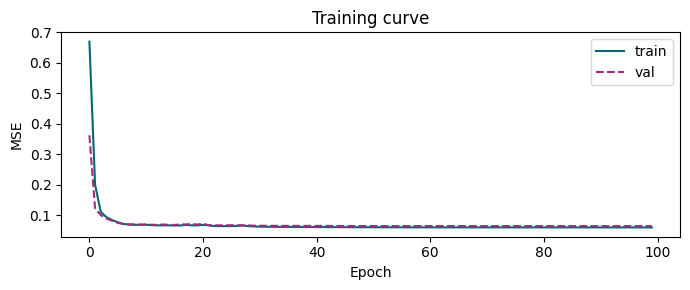

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history.history['loss'],     color='#01696f', label='train')
ax.plot(history.history['val_loss'], color='#a12c7b', ls='--', label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title('Training curve')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Reconstruction fidelity (healthy val)

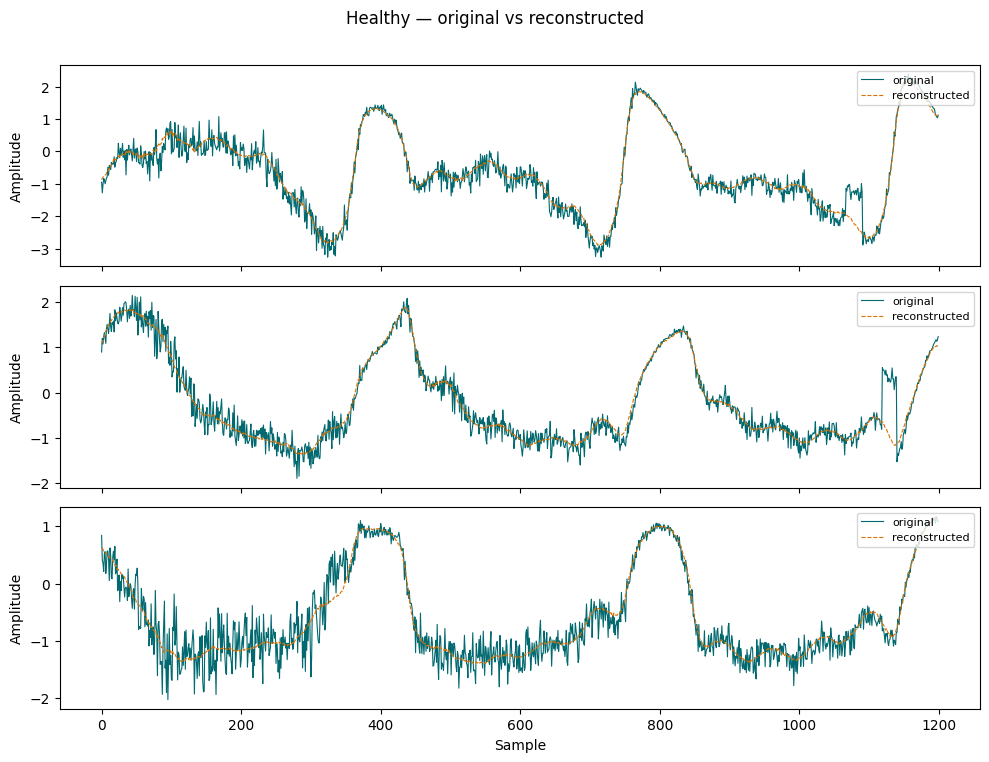

In [7]:
def per_sample_mse(model, X):
    """Per-sample reconstruction MSE — shape (N,)."""
    Xr = model.predict(X, verbose=0)
    return np.mean((X[:, :, 0] - Xr[:, :, 0]) ** 2, axis=1)

n_show = 3
idx    = np.random.choice(len(X_val), n_show, replace=False)
preds  = ae.predict(X_val[idx], verbose=0)

fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.5 * n_show), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(X_val[idx[k], :, 0], color='#01696f', lw=0.8, label='original')
    ax.plot(preds[k, :, 0],      color='#da7101', lw=0.8, ls='--', label='reconstructed')
    ax.set_ylabel('Amplitude'); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Sample')
fig.suptitle('Healthy — original vs reconstructed', y=1.01)
plt.tight_layout(); plt.show()

## 6. Per-regime MSE distributions

Sanity check: healthy signals cluster at low MSE; fault regimes shift higher.
These distributions come from **independent** samples per regime — no mixing.

Healthy       mean=0.0630  std=0.0248
Outer Race    mean=0.2915  std=0.0970
Inner Race    mean=0.4947  std=0.1814
Ball Fault    mean=0.1939  std=0.0592


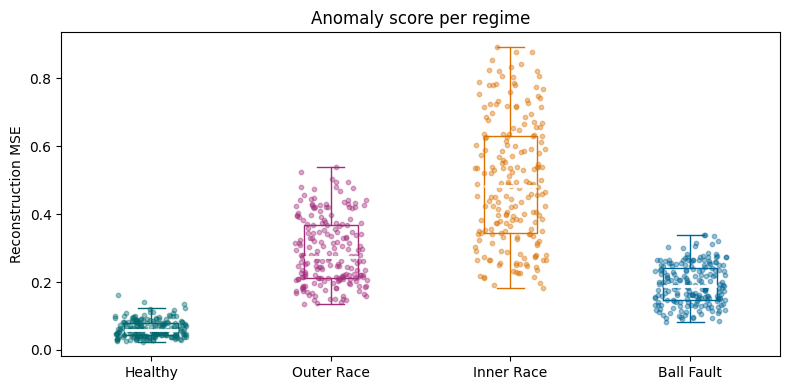

In [8]:
mse_per_regime = {r: per_sample_mse(ae, X_test_by_regime[r]) for r in REGIMES}

for r, label in zip(REGIMES, LABELS):
    m = mse_per_regime[r]
    print(f'{label:12s}  mean={m.mean():.4f}  std={m.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
for i, (regime, label, color) in enumerate(zip(REGIMES, LABELS, COLORS)):
    mse = mse_per_regime[regime]
    ax.scatter(
        np.full_like(mse, i) + np.random.uniform(-0.2, 0.2, len(mse)),
        mse, alpha=0.4, s=10, color=color, label=label)
    ax.boxplot(mse, positions=[i], widths=0.3,
               boxprops=dict(color=color), whiskerprops=dict(color=color),
               capprops=dict(color=color), medianprops=dict(color='white', lw=2),
               flierprops=dict(marker=''))
ax.set_xticks(range(len(REGIMES))); ax.set_xticklabels(LABELS)
ax.set_ylabel('Reconstruction MSE'); ax.set_title('Anomaly score per regime')
plt.tight_layout(); plt.show()

## 7. MC threshold calibration → derive z_MC

From the **healthy val set** we compute the static reference threshold and the
z-score that encodes its statistical meaning:

$$z_{\text{MC}} = \frac{\tau_{\text{MC}} - \mu_{\text{MC}}}{\sigma_{\text{MC}}}$$

This z-score is **shared across all bearings** — it represents the desired
false-alarm level on healthy operation, independent of absolute MSE scale.

MC calibration  μ=0.0635  σ=0.0240
τ_MC (99th pct) = 0.1261   →  z_MC = 2.61


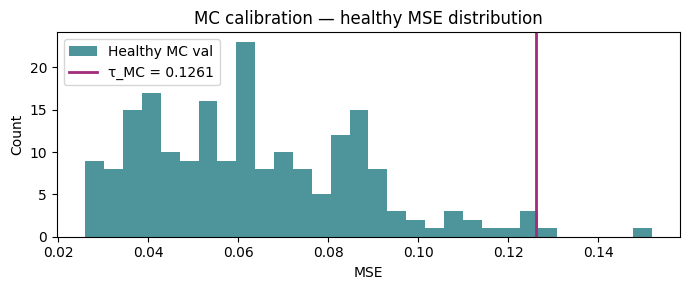

In [9]:
mse_mc = per_sample_mse(ae, X_val)   # healthy MC calibration set

mu_mc  = mse_mc.mean()
std_mc = mse_mc.std()

PERCENTILE = 99
tau_mc = np.percentile(mse_mc, PERCENTILE)
z_mc   = (tau_mc - mu_mc) / std_mc

print(f'MC calibration  μ={mu_mc:.4f}  σ={std_mc:.4f}')
print(f'τ_MC ({PERCENTILE}th pct) = {tau_mc:.4f}   →  z_MC = {z_mc:.2f}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(mse_mc, bins=30, color='#01696f', alpha=0.7, label='Healthy MC val')
ax.axvline(tau_mc, color='#a12c7b', lw=2, label=f'τ_MC = {tau_mc:.4f}')
ax.set_xlabel('MSE'); ax.set_ylabel('Count')
ax.set_title('MC calibration — healthy MSE distribution')
ax.legend(); plt.tight_layout(); plt.show()

## 8. AdaptiveTau — per-bearing sliding window

One instance per physical bearing. Each instance:
- Maintains its **own** rolling buffer of MSE values.
- Computes μ_t and σ_t **locally** from that buffer.
- Applies: **τ_t = μ_t + z_MC · σ_t** (shared z-score, local scale).
- Updates the buffer **only** with non-anomalous samples → no fault contamination.
- Pre-seeded with the MC val distribution for a warm, meaningful start.

```
bearing_A  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)   # independent!
bearing_B  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)   # independent!
bearing_C  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)   # independent!
bearing_D  →  AdaptiveTau(z_mc, window_size=WINDOW_SIZE)   # independent!
```

In [10]:
# ── Main tuning knob ────────────────────────────────────────────────────────
WINDOW_SIZE = 200   # try 100 / 200 / 500 — see Section 10 for sensitivity


class AdaptiveTau:
    """
    Per-bearing sliding-window threshold estimator.

    Parameters
    ----------
    z_mc        : float  – shared z-score from MC calibration
    window_size : int    – rolling buffer length (healthy samples only)
    warmup      : int    – min samples before using dynamic τ; tau_init used before
    tau_init    : float  – static fallback during warm-up (typically tau_mc)
    """
    def __init__(self, z_mc: float, window_size: int = 200,
                 warmup: int = 50, tau_init: float = None):
        self.z_mc        = z_mc
        self.window_size = window_size
        self.warmup      = warmup
        self.tau_init    = tau_init
        self._buf        = deque(maxlen=window_size)

    def seed(self, mse_array: np.ndarray):
        """Pre-fill buffer with known-healthy values (e.g. MC val set)."""
        for v in mse_array[-self.window_size:]:
            self._buf.append(float(v))

    def update(self, mse_value: float):
        """
        Process one new observation.
        Returns (mu_t, sigma_t, tau_t, is_anomaly).
        Buffer is updated ONLY when the sample is NOT anomalous.
        """
        if len(self._buf) < max(2, self.warmup):
            tau   = self.tau_init if self.tau_init is not None else np.inf
            mu    = float(np.mean(list(self._buf))) if self._buf else 0.0
            sigma = float(np.std(list(self._buf)))  if len(self._buf) > 1 else 0.0
        else:
            arr   = np.array(self._buf)
            mu    = float(arr.mean())
            sigma = float(arr.std())
            tau   = mu + self.z_mc * sigma

        is_anomaly = bool(mse_value > tau)
        if not is_anomaly:
            self._buf.append(float(mse_value))
        return mu, sigma, tau, is_anomaly


print(f'AdaptiveTau defined  |  z_MC={z_mc:.2f}  default window={WINDOW_SIZE}')

AdaptiveTau defined  |  z_MC=2.61  default window=200


## 9. Per-bearing experiment

We simulate **4 independent bearings** running in parallel.
All use the **same trained AE**, but each has its **own** `AdaptiveTau`.

| Bearing | Scenario | Stream |
|---------|----------|--------|
| A | Always healthy (control) | 200 healthy samples |
| B | Outer-race fault develops | 100 healthy → 100 outer_race |
| C | Inner-race fault develops | 100 healthy → 100 inner_race |
| D | Ball fault develops | 100 healthy → 100 ball_fault |

Each tracker is seeded identically from `mse_mc` (same warm start),
then evolves **independently** based on what that bearing experiences.

In [11]:
BEARINGS = {
    'Bearing A\n(always healthy)':  [('healthy',    200)],
    'Bearing B\n(outer-race fault)': [('healthy',    100), ('outer_race', 100)],
    'Bearing C\n(inner-race fault)': [('healthy',    100), ('inner_race', 100)],
    'Bearing D\n(ball fault)':       [('healthy',    100), ('ball_fault', 100)],
}

bearing_results = {}

for bearing_name, scenario in BEARINGS.items():
    # build stream for this bearing
    stream_X = np.concatenate(
        [X_test_by_regime[r][:n] for r, n in scenario], axis=0
    )

    # batch MSE inference (shared AE)
    stream_mse = per_sample_mse(ae, stream_X)

    # fresh AdaptiveTau — independent per bearing
    tracker = AdaptiveTau(z_mc=z_mc, window_size=WINDOW_SIZE,
                          warmup=50, tau_init=tau_mc)
    tracker.seed(mse_mc)

    mus, sigmas, taus, flags = [], [], [], []
    for val in stream_mse:
        mu_t, sig_t, tau_t, flag = tracker.update(val)
        mus.append(mu_t); sigmas.append(sig_t)
        taus.append(tau_t); flags.append(flag)

    bearing_results[bearing_name] = dict(
        mse=stream_mse,
        taus=np.array(taus),
        mus=np.array(mus),
        sigmas=np.array(sigmas),
        flags=np.array(flags),
        scenario=scenario,
    )

# ── Print metrics ─────────────────────────────────────────────────────────────
print(f'{"Bearing":<32} {"FAR (healthy)":>18} {"DR (fault)":>14}')
print('-' * 66)
for bname, res in bearing_results.items():
    n_healthy = sum(n for r, n in res['scenario'] if r == 'healthy')
    n_fault   = sum(n for r, n in res['scenario'] if r != 'healthy')
    far = res['flags'][:n_healthy].sum() / n_healthy
    dr  = res['flags'][n_healthy:].sum() / n_fault if n_fault else float('nan')
    label = bname.replace('\n', ' ')
    far_s = f'{far:.3f} ({int(res["flags"][:n_healthy].sum())}/{n_healthy})'
    dr_s  = f'{dr:.3f} ({int(res["flags"][n_healthy:].sum())}/{n_fault})' if n_fault else 'N/A'
    print(f'{label:<32} {far_s:>18} {dr_s:>14}')

Bearing                               FAR (healthy)     DR (fault)
------------------------------------------------------------------
Bearing A (always healthy)            0.020 (4/200)            N/A
Bearing B (outer-race fault)          0.020 (2/100) 1.000 (100/100)
Bearing C (inner-race fault)          0.020 (2/100) 1.000 (100/100)
Bearing D (ball fault)                0.020 (2/100) 0.870 (87/100)


/var/folders/8c/dj1mc34n41j8l5wb58xh_k100000gn/T/ipykernel_70520/2977528235.py:36: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


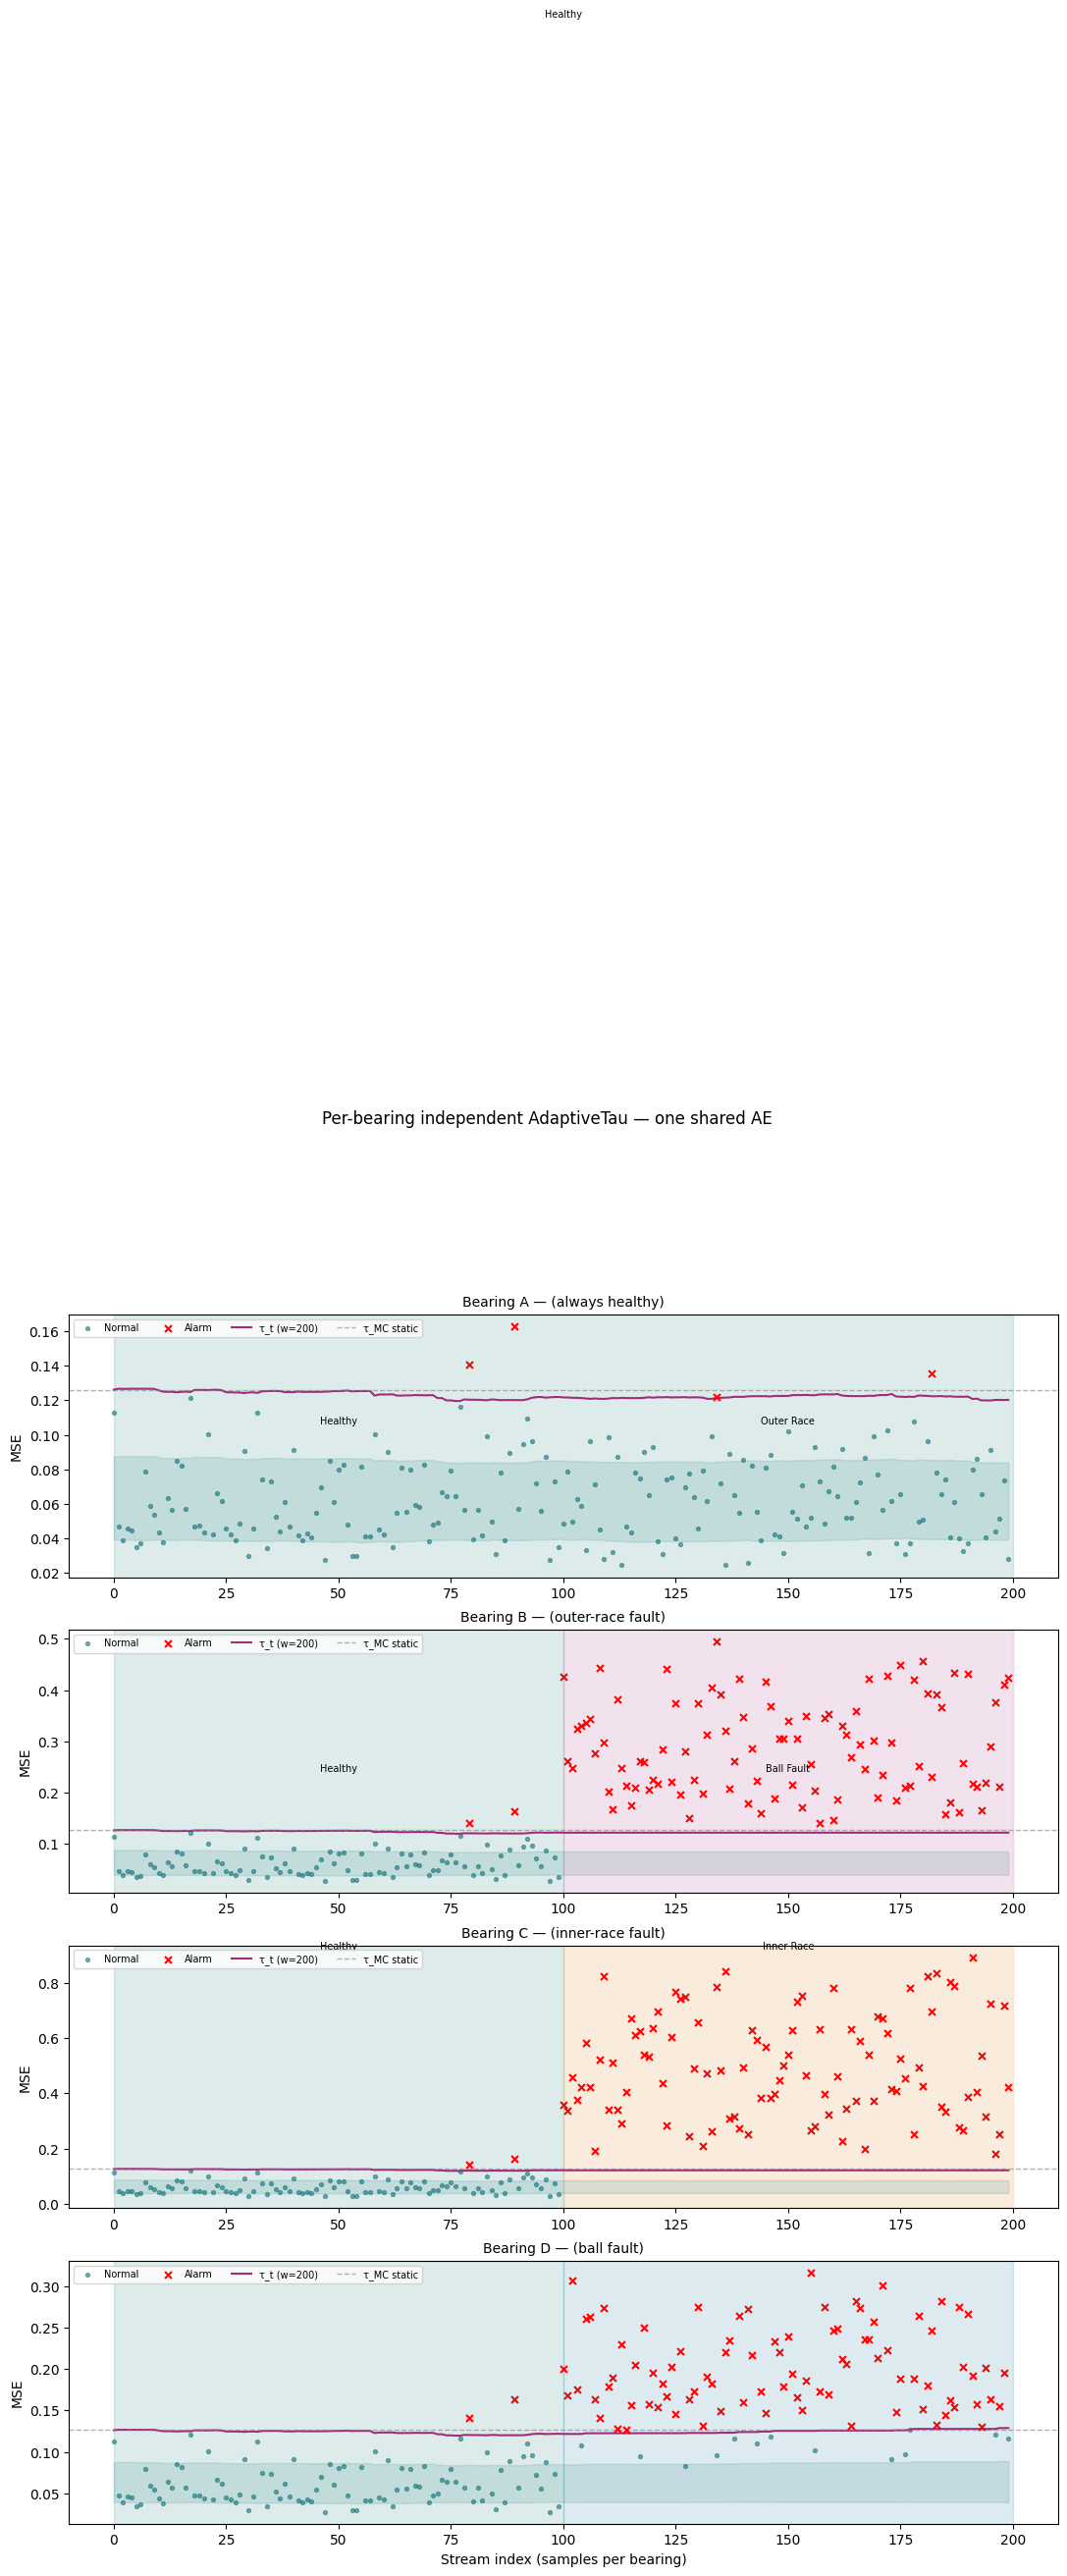

In [12]:
fig, axes = plt.subplots(len(BEARINGS), 1,
                          figsize=(13, 4 * len(BEARINGS)), sharex=False)

for ax, (bname, res) in zip(axes, bearing_results.items()):
    t       = np.arange(len(res['mse']))
    flags   = res['flags']
    scenario = res['scenario']

    # shade background per segment
    cursor = 0
    for regime, n in scenario:
        bg = COLORS[REGIMES.index(regime)] + '22'
        ax.axvspan(cursor, cursor + n, color=bg, zorder=0)
        ax.text(cursor + n / 2, ax.get_ylim()[1] * 0.92,
                LABELS[REGIMES.index(regime)], ha='center', fontsize=7)
        cursor += n

    # MSE scatter
    ax.scatter(t[~flags], res['mse'][~flags], s=8,  color='#01696f', alpha=0.5, label='Normal')
    ax.scatter(t[ flags], res['mse'][ flags], s=25, color='red', marker='x', zorder=5, label='Alarm')

    # dynamic threshold + uncertainty band
    ax.plot(t, res['taus'], color='#a12c7b', lw=1.5, label=f'τ_t (w={WINDOW_SIZE})')
    ax.axhline(tau_mc, color='gray', lw=1, ls='--', alpha=0.6, label='τ_MC static')
    ax.fill_between(t,
                    res['mus'] - res['sigmas'],
                    res['mus'] + res['sigmas'],
                    color='#01696f', alpha=0.12)

    ax.set_title(bname.replace('\n', ' — '), fontsize=10)
    ax.set_ylabel('MSE')
    ax.legend(fontsize=7, loc='upper left', ncol=4)

axes[-1].set_xlabel('Stream index (samples per bearing)')
fig.suptitle('Per-bearing independent AdaptiveTau — one shared AE', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 10. Window size sensitivity

Sweep `WINDOW_SIZE` and compare False Alarm Rate vs Detection Rate
averaged across the three fault bearings (B, C, D).
Use this curve to pick the right operating point for your installation.

window=   50  FAR=0.030  DR=0.940
window=  100  FAR=0.020  DR=0.953
window=  200  FAR=0.020  DR=0.957
window=  500  FAR=0.020  DR=0.957
window= 1000  FAR=0.020  DR=0.957


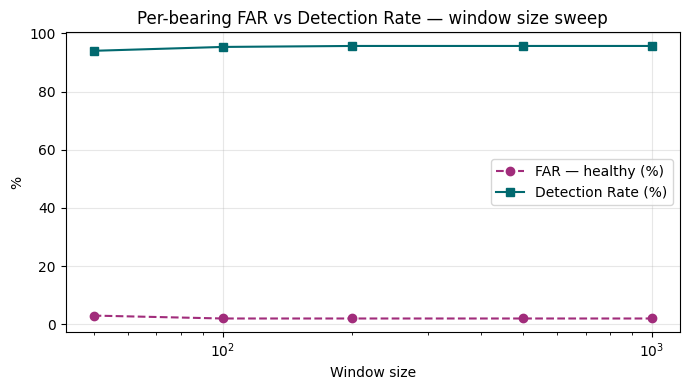

In [13]:
window_sizes = [50, 100, 200, 500, 1000]
sweep = []

fault_scenarios = [
    ('outer_race', 100),
    ('inner_race', 100),
    ('ball_fault', 100),
]

for ws in window_sizes:
    far_list, dr_list = [], []
    for fault_regime, n_fault in fault_scenarios:
        X_h = X_test_by_regime['healthy'][:100]
        X_f = X_test_by_regime[fault_regime][:n_fault]
        stream = np.concatenate([X_h, X_f], axis=0)
        mse    = per_sample_mse(ae, stream)

        tr = AdaptiveTau(z_mc=z_mc, window_size=ws,
                         warmup=min(ws // 4, 50), tau_init=tau_mc)
        tr.seed(mse_mc)
        flgs = np.array([tr.update(v)[3] for v in mse])
        far_list.append(flgs[:100].sum() / 100)
        dr_list.append(flgs[100:].sum()  / n_fault)

    sweep.append((ws, np.mean(far_list), np.mean(dr_list)))
    print(f'window={ws:5d}  FAR={np.mean(far_list):.3f}  DR={np.mean(dr_list):.3f}')

res_sw = np.array(sweep)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res_sw[:, 0], res_sw[:, 1] * 100, 'o--', color='#a12c7b', label='FAR — healthy (%)')
ax.plot(res_sw[:, 0], res_sw[:, 2] * 100, 's-',  color='#01696f', label='Detection Rate (%)')
ax.set_xscale('log'); ax.set_xlabel('Window size'); ax.set_ylabel('%')
ax.set_title('Per-bearing FAR vs Detection Rate — window size sweep')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Latent space geometry (PCA)

Even though the AE was trained only on healthy signals,
the 16-dim latent space shows natural separation between regimes —
confirming the quotient structure of M_healthy.

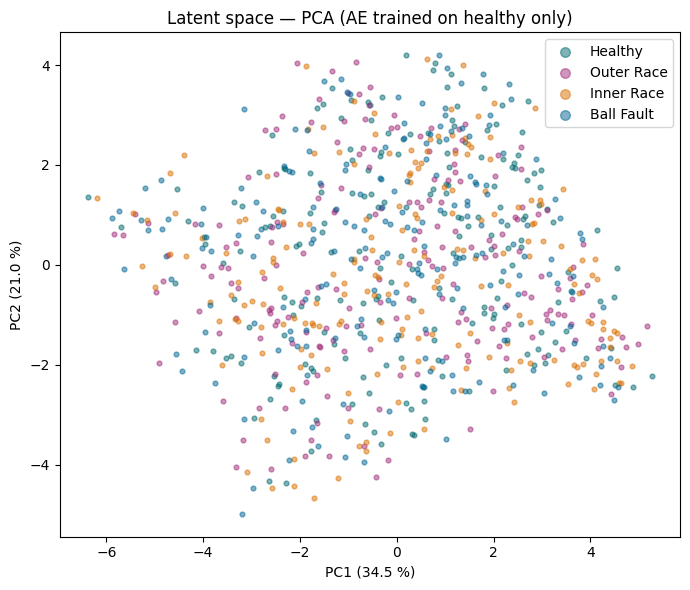

In [14]:
X_all = np.concatenate([X_test_by_regime[r] for r in REGIMES], axis=0)
y_all = np.concatenate([[i] * N_TEST for i in range(len(REGIMES))])

Z_all = encoder.predict(X_all, verbose=0)
pca   = PCA(n_components=2)
Z2    = pca.fit_transform(Z_all)

fig, ax = plt.subplots(figsize=(7, 6))
for i, (label, color) in enumerate(zip(LABELS, COLORS)):
    mask = y_all == i
    ax.scatter(Z2[mask, 0], Z2[mask, 1], s=12, alpha=0.5, color=color, label=label)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)')
ax.set_title('Latent space — PCA (AE trained on healthy only)')
ax.legend(markerscale=2); plt.tight_layout(); plt.show()

## 12. Summary

| Component | Details |
|---|---|
| **AE** | Trained once on healthy MC signals — **shared** across all bearings |
| **z_MC** | Derived from healthy val set — **shared**, encodes desired FAR level |
| **AdaptiveTau** | One instance **per bearing** — independent buffer, μ_t, σ_t |
| **Buffer guard** | Anomalous samples never enter the buffer → no fault contamination |
| **Warm-up + seed** | Buffer pre-filled from MC val; τ_MC used as fallback until warm |
| **WINDOW_SIZE** | Main deployment knob — tune via Section 10 FAR/DR curve |

**Deployment pattern:**
```python
# At startup — one tracker per physical bearing
trackers = {
    'bearing_001': AdaptiveTau(z_mc, window_size=WINDOW_SIZE, tau_init=tau_mc),
    'bearing_002': AdaptiveTau(z_mc, window_size=WINDOW_SIZE, tau_init=tau_mc),
    # ...
}
for tr in trackers.values():
    tr.seed(mse_mc)   # same warm start for all

# At runtime — per bearing, per new measurement
mse = per_sample_mse(ae, new_signal[np.newaxis])[0]
mu, sigma, tau, alarm = trackers['bearing_001'].update(mse)
if alarm:
    print('⚠️  Anomaly detected in bearing_001')
```